In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [162]:
train_df = pd.read_csv("/Users/apple/Documents/Projects/Nasa RUL MLE/data/raw/train.csv")
test_df = pd.read_csv("/Users/apple/Documents/Projects/Nasa RUL MLE/data/raw/test.csv")
rul_df = pd.read_csv("/Users/apple/Documents/Projects/Nasa RUL MLE/data/raw/rul.csv")

In [163]:
print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)
print("rul_df shape:", rul_df.shape)

train_df shape: (20631, 27)
test_df shape: (13096, 26)
rul_df shape: (100, 1)


In [164]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 27 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting_1  20631 non-null  float64
 3   setting_2  20631 non-null  float64
 4   setting_3  20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor_16  20631 

In [165]:
train_df.describe()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,rul
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705,86.829286
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251,41.673699
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200,0.000000
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800,51.000000
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900,103.000000
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800,125.000000
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400,125.000000


In [166]:
train_df["engine_id"].nunique()
test_df["engine_id"].nunique()

train_lengths = train_df.groupby("engine_id")["cycle"].max()

train_lengths.describe()

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

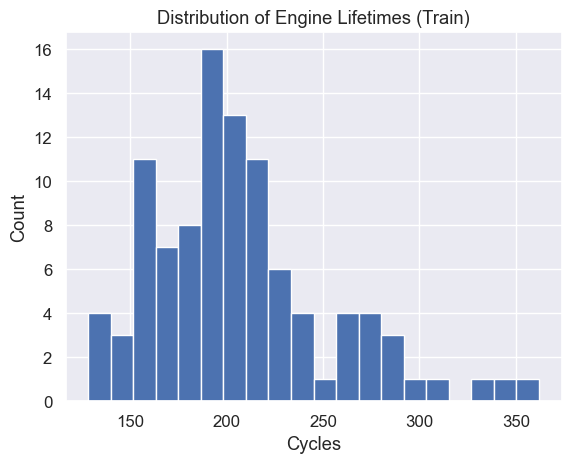

In [167]:
plt.figure()
train_lengths.hist(bins=20)
plt.title("Distribution of Engine Lifetimes (Train)")
plt.xlabel("Cycles")
plt.ylabel("Count")
plt.show()

most of engines have lifetimes around 180-220 cycles

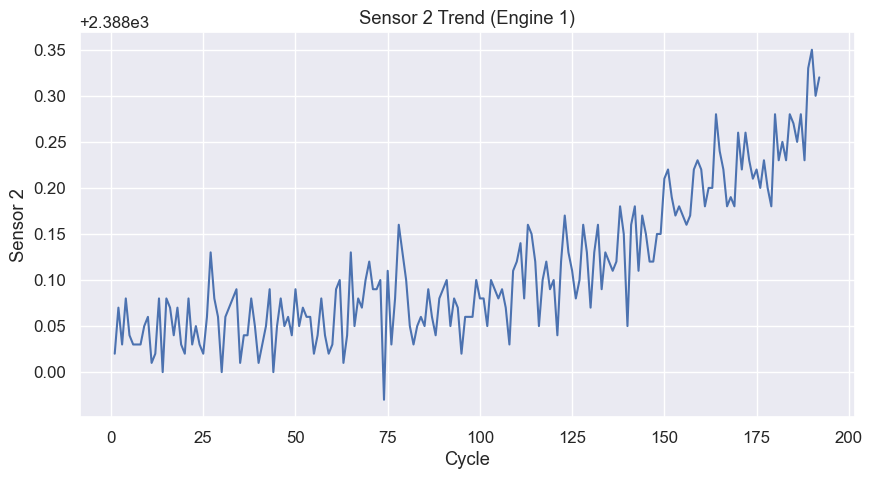

In [168]:
# sensor behaviour overtime
engine_id = 1
engine_data = train_df[train_df["engine_id"] == engine_id]

plt.figure(figsize=(10,5))
plt.plot(engine_data["cycle"], engine_data["sensor_13"])
plt.title(f"Sensor 2 Trend (Engine {engine_id})")
plt.xlabel("Cycle")
plt.ylabel("Sensor 2")
plt.show()

flat behavior mean useless sensor, does not have effect on rul

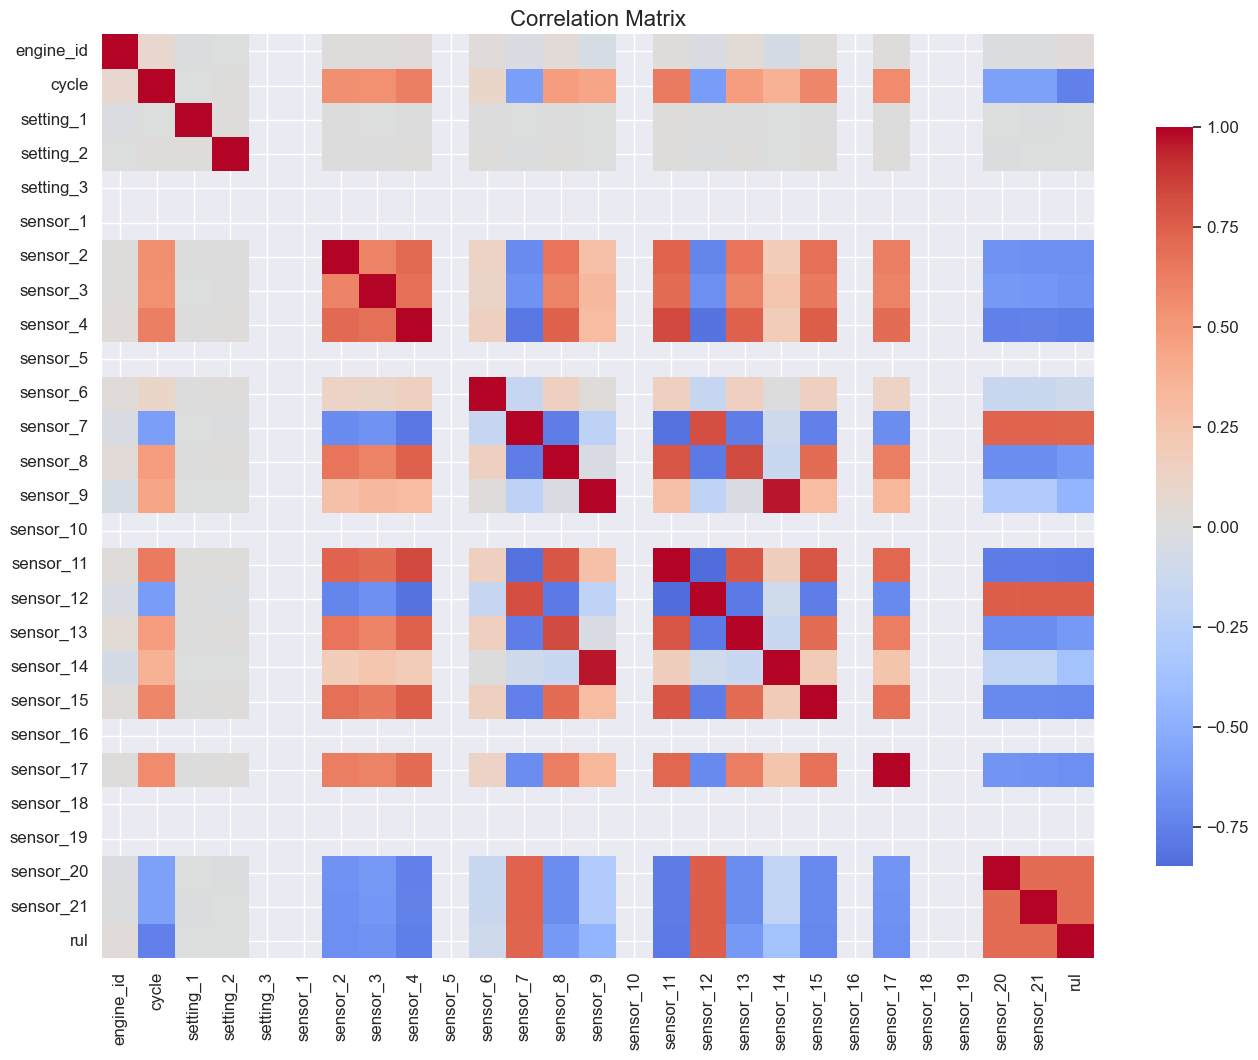

In [169]:
# Compute correlation matrix
corr = train_df.corr()

# Display full matrix as heatmap
plt.figure(figsize=(16,12))
sns.heatmap(
    corr, 
    cmap="coolwarm", 
    center=0, 
    annot=False,   # set to True if you want numbers on cells
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix", fontsize=16)
plt.show()

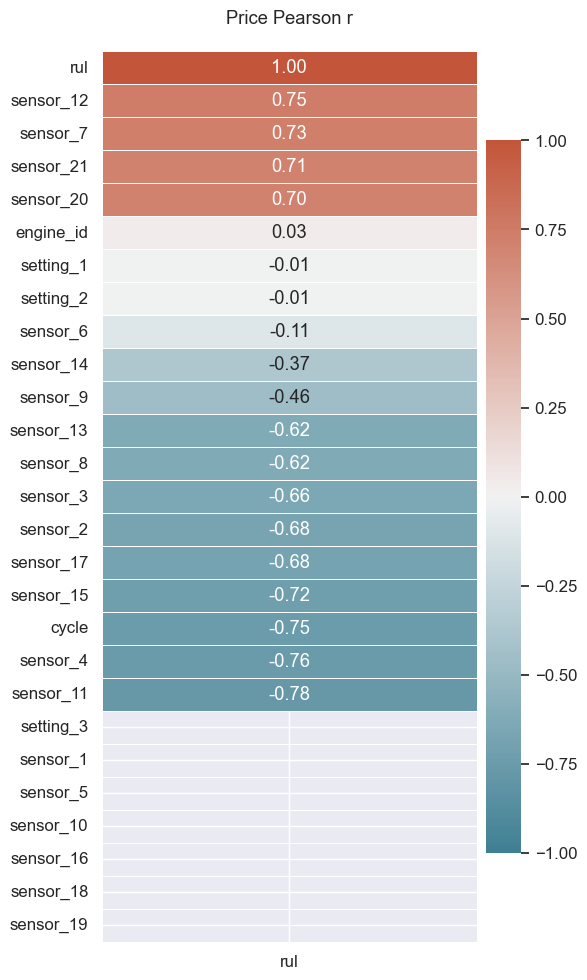

In [170]:
# Compute correlations with rul
rul_corr_p = train_df.corr(method="pearson")["rul"]

sns.set_theme(style="white")     
sns.set(font_scale=1.1)          
plt.figure(figsize=(6,10))       
ax = sns.heatmap(
        rul_corr_p.sort_values(ascending=False).to_frame(),     
        annot=True, fmt=".2f",
        vmin=-1, vmax=1,         
        cmap=sns.diverging_palette(220, 20, as_cmap=True),
        center=0,
        linewidths=.5, linecolor="white",
        cbar_kws={"shrink":0.8, "pad":0.02}
     )
ax.set_title("Price Pearson r", pad=20)
ax.set_ylabel("")                 
ax.set_xlabel("")
plt.tight_layout()
plt.show()

we dont need sensor 1, 3, 5, 10, 16, 18, and 19

In [171]:
# Drop uncorrelated columns
DROP_COLUMNS = [
    "sensor_1", "sensor_5", "sensor_10", "sensor_16", "sensor_18", "sensor_19"
]

train_df = train_df.drop(columns=DROP_COLUMNS, errors="ignore")

In [172]:
test_df = test_df.drop(columns=DROP_COLUMNS, errors="ignore")

In [173]:
print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)
print("rul_df shape:", rul_df.shape)

train_df shape: (20631, 21)
test_df shape: (13096, 20)
rul_df shape: (100, 1)


In [174]:
# save clean data
train_df.to_csv("/Users/apple/Documents/Projects/Nasa RUL MLE/data/processed/clean_train.csv", index=False)
test_df.to_csv("/Users/apple/Documents/Projects/Nasa RUL MLE/data/processed/clean_test.csv", index=False)
rul_df.to_csv("/Users/apple/Documents/Projects/Nasa RUL MLE/data/processed/clean_rul.csv", index=False)